# Machine Learning - Session 5

## Neural Networks

### Step 1: Library Imports

* **`load_breast_cancer`**: Built-in benchmark dataset for binary medical classification.
* **`train_test_split`**: Splits data into training and validation/test subsets.
* **`StandardScaler`**: Scales features to zero mean ($\mu = 0$) and unit variance ($\sigma = 1$).
* **`MLPClassifier`**: Scikit-learn's feedforward artificial neural network (Multi-Layer Perceptron).
* **`classification_report`, `confusion_matrix`, `accuracy_score`**: Standard evaluation tools.
* **`matplotlib.pyplot`**: Plotting training curves and activation functions.

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

### Step 2: Dataset Exploration

* **Dataset Shape**: `(569, 30)` — $569$ samples and $30$ numerical features (e.g., mean radius, texture, perimeter).
* **Target Classes**: `['malignant', 'benign']` (encoded as binary `0` and `1`).

In [2]:
# type: ignore
data = load_breast_cancer()
X = data.data
y = data.target

print("Feature names:", data.feature_names)
print("Target names:", data.target_names)
print("Data shape:", X.shape)

Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Target names: ['malignant' 'benign']
Data shape: (569, 30)


### Step 3: Train-Test Split & Feature Scaling

**Why Scaling is Critical for Neural Networks:**

1. **Gradient Descent Stability**: Unscaled features with large numerical ranges dominate weight updates and cause oscillations or exploding/vanishing gradients.
2. **Faster Convergence**: Normalized inputs allow gradient descent / Adam optimizer to converge much faster.
3. **Data Leakage Prevention**:
   * `scaler.fit_transform(X_train)`: Computes $\mu$ and $\sigma$ strictly from the **training set** and transforms it.
   * `scaler.transform(X_test)`: Uses the **training statistics** to transform the test set without learning from it.

In [3]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Step 4: Model Architecture & Training (`MLPClassifier`)

* **Network Architecture**:
  * **Input Layer**: $30$ neurons (matches the number of input features).
  * **Hidden Layer 1**: $10$ neurons.
  * **Hidden Layer 2**: $5$ neurons.
  * **Output Layer**: Binary classification output.
* **Hyperparameters**:
  * `hidden_layer_sizes=(10, 5)`: Defines depth (2 hidden layers) and width (10 and 5 neurons).
  * `max_iter=1000`: Number of training epochs allowed before stopping if convergence is not reached.
  * `random_state=1`: Ensures reproducible weight initialization and shuffle orders.
* **Default Scikit-Learn Settings Applied Behind the Scenes**:
  * **Activation**: `activation='relu'` (Rectified Linear Unit for hidden layers).
  * **Optimizer**: `solver='adam'` (Adaptive Moment Estimation).
  * **Loss Function**: Binary Cross-Entropy (Log-loss).

In [4]:
mlp = MLPClassifier(hidden_layer_sizes=(10, 5), max_iter=1000, random_state=1)

mlp.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(10, ...)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",1
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


### Step 5: Prediction & Model Evaluation

* **Output Results**:
  * **Accuracy**: $\approx 98.25\%$ ($112$ out of $114$ correct predictions).
  * **Confusion Matrix**:
    $$\begin{bmatrix} 42 & 1 \\ 1 & 70 \end{bmatrix}$$
    * 42 True Malignant (Class 0), 1 False Positive.
    * 70 True Benign (Class 1), 1 False Negative.
* **Metrics Interpreted**:
  * **Precision** ($\frac{TP}{TP + FP}$): Out of all positive predictions, how many were correct? ($\approx 98\%\text{--}99\%$)
  * **Recall** ($\frac{TP}{TP + FN}$): Out of all actual positives, how many did the model detect? ($\approx 98\%\text{--}99\%$)
  * **F1-Score**: Harmonic mean of Precision and Recall ($2 \times \frac{P \times R}{P + R}$).

In [5]:
# type: ignore
y_pred = mlp.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

print("Accuracy:", accuracy_score(y_test, y_pred))

Confusion Matrix:
[[42  1]
 [ 1 70]]

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        43
      benign       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Accuracy: 0.9824561403508771


### Step 6: Visualizing the Loss Curve

* **`mlp.loss_curve_`**: Records the value of the loss function at each iteration (epoch).
* **Takeaway**: A smoothly descending curve that plateaus near zero demonstrates healthy convergence without wild oscillations or early divergence.

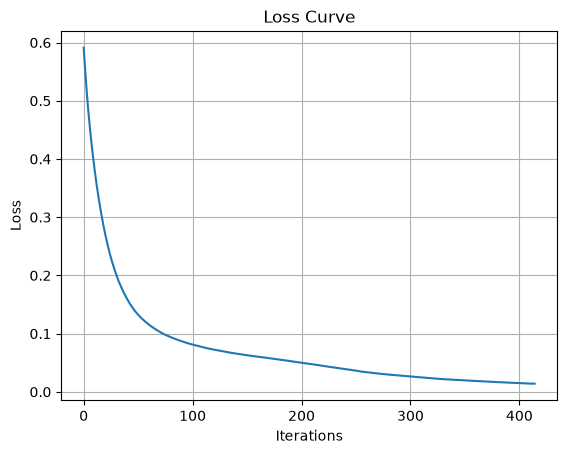

In [6]:
plt.plot(mlp.loss_curve_)
plt.title("Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

### Bonus: Activation Functions

| Activation | Formula | Pros | Cons / Notes |
| :--- | :--- | :--- | :--- |
| **ReLU** | $f(x) = \max(0, x)$ | Computationally efficient; reduces vanishing gradient for $x > 0$. | **Dying ReLU problem**: If $x \le 0$, gradient is 0 and neuron permanently deactivates. |
| **Leaky ReLU** | $f(x) = x \text{ if } x > 0 \text{ else } \alpha x$ | Small slope ($\alpha = 0.1$) for $x < 0$ prevents dying neurons. | Requires selecting slope $\alpha$. |
| **ELU** | $f(x) = x \text{ if } x > 0 \text{ else } \alpha(e^x - 1)$ | Smooth transition at 0; negative saturation brings mean activation closer to 0. | Slightly higher computational cost due to $\exp(x)$. |
| **GELU** | $f(x) = x \cdot \Phi(x)$ | Smooth, non-monotonic; probabilistically retains inputs. | Industry standard in modern Transformers (BERT, GPT, ViT). |

**Key Visual Differences to Note**

- **ReLU:** Flat at zero for all negative values, creating a sharp angle at x=0.
    
- **LeakyReLU:** Shows a steady downward-sloping linear line for negative values, ensuring non-zero gradients.
    
- **ELU:** Smoothly curves down toward an asymptote at y=−1.0 for negative inputs.
    
- **GELU:** Features a subtle, non-monotonic dip below zero near x=−1.0 before smoothly flattening out.

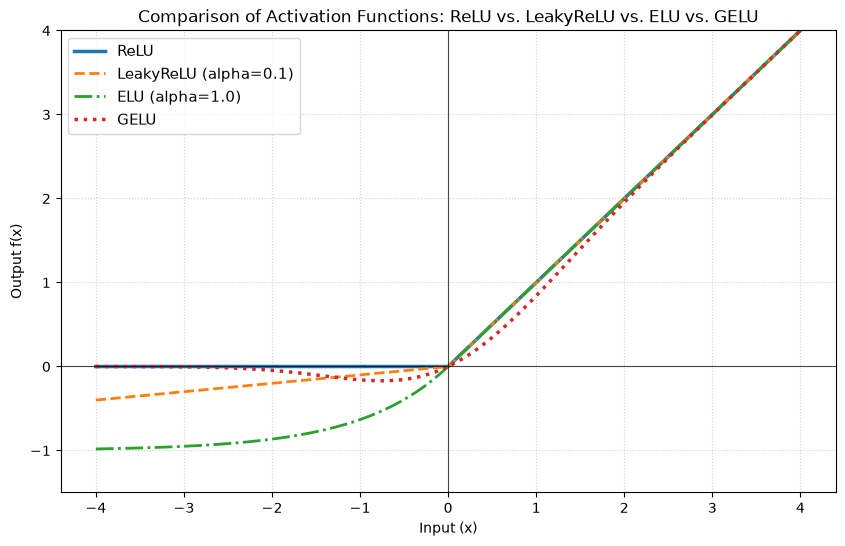

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Define activation functions
def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.1):
    return np.where(x > 0, x, alpha * x)

def elu(x, alpha=1.0):
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))

def gelu(x):
    return x * norm.cdf(x)

# 2. Generate input range
x = np.linspace(-4, 4, 1000)

# 3. Plotting
plt.figure(figsize=(10, 6))

plt.plot(x, relu(x), label="ReLU", linewidth=2.5)
plt.plot(x, leaky_relu(x), label="LeakyReLU (alpha=0.1)", linewidth=2, linestyle="--")
plt.plot(x, elu(x), label="ELU (alpha=1.0)", linewidth=2, linestyle="-.")
plt.plot(x, gelu(x), label="GELU", linewidth=2.5, linestyle=":")

# 4. Styling and Layout
plt.axhline(0, color="black", linestyle="-", linewidth=0.8, alpha=0.7)
plt.axvline(0, color="black", linestyle="-", linewidth=0.8, alpha=0.7)
plt.title("Comparison of Activation Functions: ReLU vs. LeakyReLU vs. ELU vs. GELU", fontsize=12)
plt.xlabel("Input (x)", fontsize=10)
plt.ylabel("Output f(x)", fontsize=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11, loc="upper left")
plt.ylim(-1.5, 4)

plt.show()